In [1]:
import pandas as pd 
df=pd.read_csv("Delivery_Logistics.csv")
print(df.shape)


(25000, 15)


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  object 
 2   package_type         25000 non-null  object 
 3   vehicle_type         25000 non-null  object 
 4   delivery_mode        25000 non-null  object 
 5   region               25000 non-null  object 
 6   weather_condition    25000 non-null  object 
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null  object 
 10  expected_time_hours  25000 non-null  object 
 11  delayed              25000 non-null  object 
 12  delivery_status      25000 non-null  object 
 13  delivery_rating      25000 non-null  int64  
 14  delivery_cost        25000 non-null  float64
dtypes: float64(4), int64(1), object(10)


In [3]:
print(df["delivery_time_hours"].head(10))

0    1970-01-01 00:00:00.000000008
1    1970-01-01 00:00:00.000000002
2    1970-01-01 00:00:00.000000010
3    1970-01-01 00:00:00.000000006
4    1970-01-01 00:00:00.000000009
5    1970-01-01 00:00:00.000000004
6    1970-01-01 00:00:00.000000006
7    1970-01-01 00:00:00.000000004
8    1970-01-01 00:00:00.000000005
9    1970-01-01 00:00:00.000000003
Name: delivery_time_hours, dtype: object


In [4]:
df[['distance_km', 'delivery_time_hours', 'delivery_mode']].head(10)

,distance_km,delivery_time_hours,delivery_mode
0,297.0,1970-01-01 00:00:00.000000008,same day
1,89.6,1970-01-01 00:00:00.000000002,express
2,273.5,1970-01-01 00:00:00.000000010,two day
3,269.7,1970-01-01 00:00:00.000000006,same day
4,256.7,1970-01-01 00:00:00.000000009,two day
5,48.4,1970-01-01 00:00:00.000000004,express
6,198.3,1970-01-01 00:00:00.000000006,same day
7,114.6,1970-01-01 00:00:00.000000004,same day
8,142.4,1970-01-01 00:00:00.000000005,same day
9,47.1,1970-01-01 00:00:00.000000003,same day


In [5]:


df[['distance_km', 'package_weight_kg', 'delivery_cost', 'delivery_rating']].describe()


,distance_km,package_weight_kg,delivery_cost,delivery_rating
count,25000.000000,25000.000000,25000.000000,25000.000000
mean,150.390436,25.145898,864.944579,3.666000
std,86.409745,14.368663,435.712593,1.149964
min,3.600000,0.670000,95.667400,1.000000
25%,75.900000,12.680000,490.800000,3.000000
50%,151.000000,25.145000,867.535000,4.000000
75%,224.900000,37.660000,1237.910000,5.000000
max,297.100000,49.520000,1632.720600,5.000000


In [6]:
df["delivery_partner"].value_counts()

delivery_partner
xpressbees          2826
fedex               2818
dhl                 2802
ekart               2801
blue dart           2798
delhivery           2786
shadowfax           2736
ecom express        2722
amazon logistics    2711
Name: count, dtype: int64

In [7]:
df['delivery_partner']=df['delivery_partner'].str.strip()

In [8]:
df['delivery_partner']=df['delivery_partner'].str.lower()
df['weather_condition'] = df['weather_condition'].str.strip()
df['delivery_partner']=df['delivery_partner'].str.lower()




In [9]:

df['weather_condition'].value_counts()


weather_condition
foggy     4219
stormy    4198
rainy     4171
cold      4158
hot       4130
clear     4124
Name: count, dtype: int64

In [10]:
df['delivery_time_hours']=pd.to_datetime(df['delivery_time_hours'])
df['expected_time_hours']=pd.to_datetime(df['expected_time_hours'])
df['delivery_time_hours']=pd.to_datetime(df['delivery_time_hours']).dt.nanosecond
df['expected_time_hours']=pd.to_datetime(df['expected_time_hours']).dt.nanosecond
df[['delivery_time_hours','distance_km','expected_time_hours','delivery_mode']].head()

,delivery_time_hours,distance_km,expected_time_hours,delivery_mode
0,8,297.0,8,same day
1,2,89.6,3,express
2,10,273.5,16,two day
3,6,269.7,8,same day
4,9,256.7,16,two day


In [11]:
df.drop(columns=['delivery_time_hours','expected_time_hours'],axis=1,inplace=True)
df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,no,delivered,4,1394.5600


In [12]:
df.shape

(25000, 13)

In [13]:
df['delivery_id']=df['delivery_id'].astype('int64')


In [14]:
df.head(10)

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,delivery_cost
0,250,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,no,delivered,3,1632.7206
1,250,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,no,delivered,5,640.1700
2,250,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,no,delivered,4,1448.1700
3,250,dhl,electronics,ev van,same day,east,cold,269.7,12.69,no,delivered,3,1486.5700
4,250,dhl,clothing,van,two day,north,foggy,256.7,37.02,no,delivered,4,1394.5600
5,250,amazon logistics,documents,ev bike,express,west,rainy,48.4,33.15,yes,delayed,3,391.4500
6,250,delhivery,groceries,scooter,same day,central,clear,198.3,43.79,no,delivered,3,1222.8700
7,250,xpressbees,fragile items,van,same day,north,cold,114.6,42.63,no,delivered,3,800.8900
8,250,blue dart,clothing,van,same day,south,hot,142.4,14.06,no,delivered,5,854.1800
9,250,delhivery,pharmacy,truck,same day,east,foggy,47.1,29.28,no,delivered,5,423.3400


In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   delivery_id        25000 non-null  int64  
 1   delivery_partner   25000 non-null  object 
 2   package_type       25000 non-null  object 
 3   vehicle_type       25000 non-null  object 
 4   delivery_mode      25000 non-null  object 
 5   region             25000 non-null  object 
 6   weather_condition  25000 non-null  object 
 7   distance_km        25000 non-null  float64
 8   package_weight_kg  25000 non-null  float64
 9   delayed            25000 non-null  object 
 10  delivery_status    25000 non-null  object 
 11  delivery_rating    25000 non-null  int64  
 12  delivery_cost      25000 non-null  float64
dtypes: float64(3), int64(2), object(8)
memory usage: 2.5+ MB


In [16]:
remaining_text_cols = ['package_type', 'vehicle_type', 'delivery_mode', 'region', 'delayed', 'delivery_status']

for col in remaining_text_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()


df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,delivery_cost
0,250,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,no,delivered,3,1632.7206
1,250,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,no,delivered,5,640.1700
2,250,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,no,delivered,4,1448.1700
3,250,dhl,electronics,ev van,same day,east,cold,269.7,12.69,no,delivered,3,1486.5700
4,250,dhl,clothing,van,two day,north,foggy,256.7,37.02,no,delivered,4,1394.5600


In [17]:
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()

df[['distance_scaled', 'weight_scaled']] = scaler.fit_transform(df[['distance_km', 'package_weight_kg']])

df[['distance_km', 'distance_scaled', 'package_weight_kg', 'weight_scaled']].head()

,distance_km,distance_scaled,package_weight_kg,weight_scaled
0,297.0,0.999659,46.96,0.947595
1,89.6,0.293015,47.39,0.956397
2,273.5,0.919591,26.89,0.536745
3,269.7,0.906644,12.69,0.246059
4,256.7,0.862351,37.02,0.744115


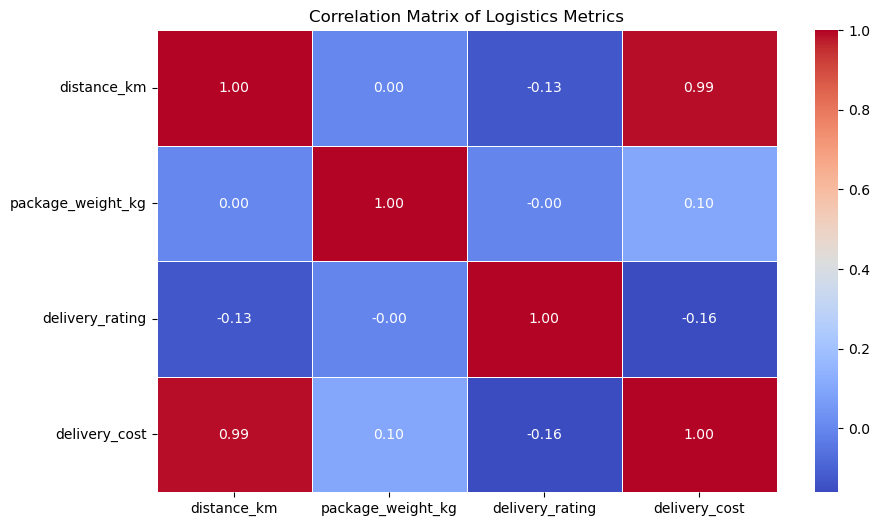

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

numeric_cols = df[['distance_km', 'package_weight_kg', 'delivery_rating', 'delivery_cost']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)


plt.title("Correlation Matrix of Logistics Metrics")
plt.show()


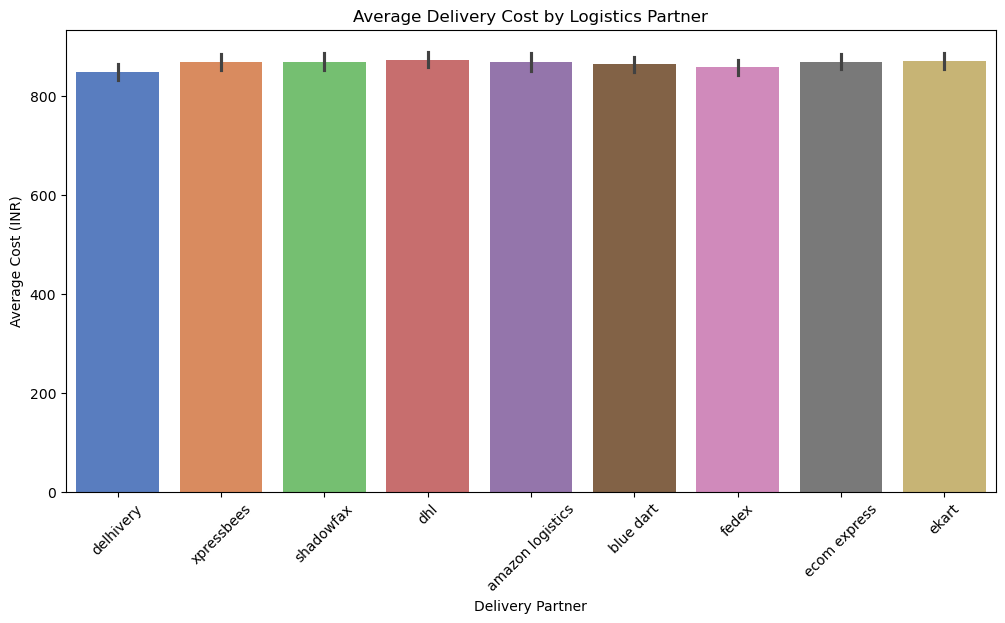

In [19]:
plt.figure(figsize=(12, 6))

sns.barplot(x='delivery_partner', y='delivery_cost', data=df, hue='delivery_partner', palette='muted', legend=False)


plt.title("Average Delivery Cost by Logistics Partner")
plt.xlabel("Delivery Partner")
plt.ylabel("Average Cost (INR)")

plt.xticks(rotation=45)
plt.show()


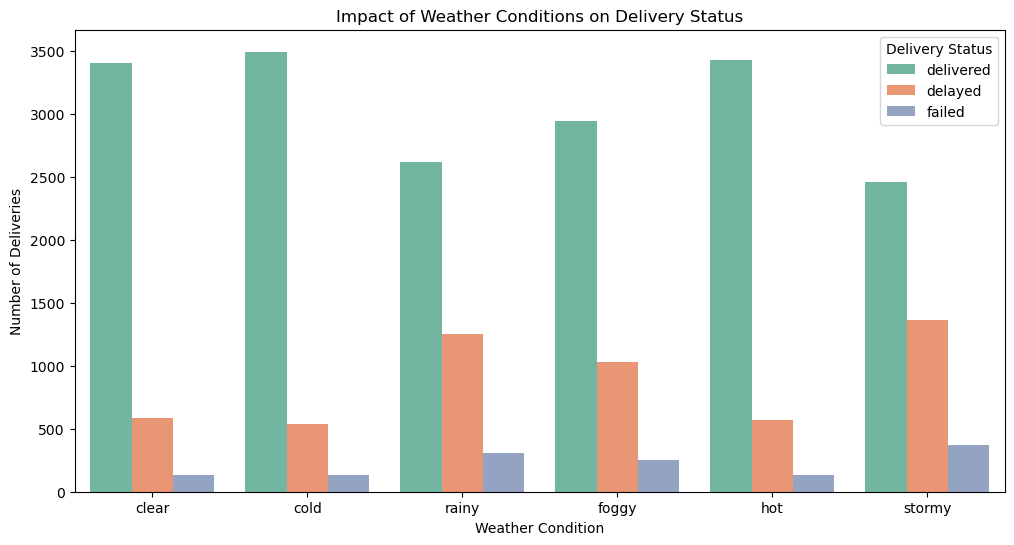

In [20]:
plt.figure(figsize=(12, 6))


sns.countplot(x='weather_condition', hue='delivery_status', data=df, palette='Set2')

plt.title("Impact of Weather Conditions on Delivery Status")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Deliveries")

plt.legend(title='Delivery Status', loc='upper right')
plt.show()

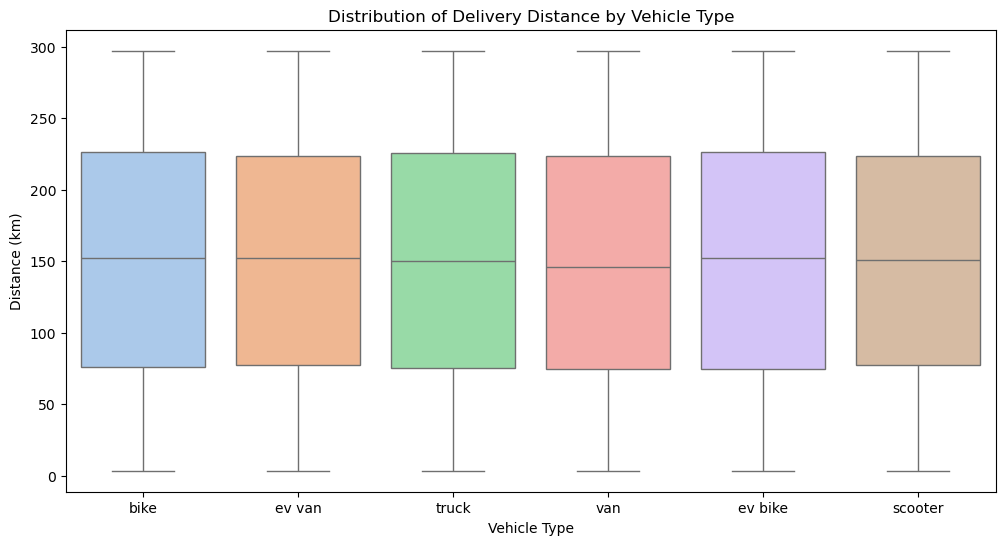

In [21]:
plt.figure(figsize=(12, 6))


sns.boxplot(x='vehicle_type', y='distance_km', data=df, hue='vehicle_type', palette='pastel', legend=False)


plt.title("Distribution of Delivery Distance by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Distance (km)")


plt.show()


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


X = df[['distance_km']] # Input 
y = df['delivery_cost']  # Target 


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("--- Model Evaluation ---")
print(f"R-squared Score : {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error : {mean_absolute_error(y_test, y_pred):.2f} INR")


--- Model Evaluation ---
R-squared Score : 0.9817
Mean Absolute Error : 48.09 INR


In [23]:
from sklearn.model_selection import cross_val_score


cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')


print("--- 5-Fold Cross-Validation ---")
print("each R-squared score:", cv_scores)
print(f"Mean CV R2: {cv_scores.mean():.4f}")


--- 5-Fold Cross-Validation ---
each R-squared score: [0.98129162 0.98139791 0.98211034 0.98163702 0.98167259]
Mean CV R2: 0.9816
